# Cite:
Jorntell, Henrik, and Kaan Kesgin. "Singular superlet transform achieves markedly improved time-frequency super-resolution for separating complex neural signals." bioRxiv (2023): 2023-02

In [1]:
#import required packages
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import importlib

import cmcrameri.cm as cmc

#import the functions
from SingularSuperletPY import sst
from SingularSuperletPY import cwt #uncomment if you want to compare the method (SST) with continuous wavelet transform (CWT)

import superlets_package.morlet as morlet
import superlets_package.superlets as superlet

In [2]:
importlib.reload(sst)

<module 'SingularSuperletPY.sst' from '/Users/neuralrehabilitationgroup/PycharmProjects/SingularSuperletPY/SingularSuperletPY/sst.py'>

In [3]:
importlib.reload(cwt)

<module 'SingularSuperletPY.cwt' from '/Users/neuralrehabilitationgroup/PycharmProjects/SingularSuperletPY/SingularSuperletPY/cwt.py'>

In [4]:
importlib.reload(superlet)

<module 'superlets_package.superlets' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/superlets.py'>

In [5]:
importlib.reload(morlet)

<module 'superlets_package.morlet' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/morlet.py'>

In [6]:
fontsize_title = 10
fontsize_subtitle = 16
fontsize_ticks = 12
fontsize_labels = 14
fontsize_legend = 14

# Create simulated EMG signals

### Burst parameters

In [7]:
Fs = 1024
signal_duration = 3
t = np.linspace(0, signal_duration, signal_duration * Fs)

### Baseline noise

In [8]:
np.random.seed(10)
noise = np.random.normal(0, 0.01, len(t))
#noise = np.random.normal(0, 0.00001, len(t))
#noise = np.array([0.00001] * len(t))

In [9]:
burst_duration = 0.5
burst_start = 1
real_t_onset = burst_start
real_t_offset = burst_start + burst_duration

In [10]:
start_idx = np.searchsorted(t, burst_start)  # Encuentra el índice de inicio
end_idx = np.searchsorted(t, burst_start + burst_duration)  # Encuentra el índice final

### De Luca method to create burst with a known frequency

MNF ideal = 92.67754020405637
MNF analytic = 96.69316491703574


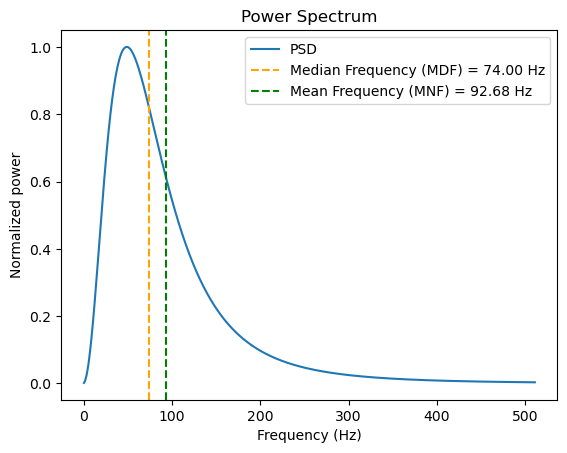

In [11]:
burst = []
[filtro, PdeLuca, burst, MNF_ideal, MNF_analytic] = superlet.fdeluca(100, 40, Fs, burst_duration, plot = False)
print(f'MNF ideal = {MNF_ideal}')
print(f'MNF analytic = {MNF_analytic}')
MNF_1 = [MNF_ideal]

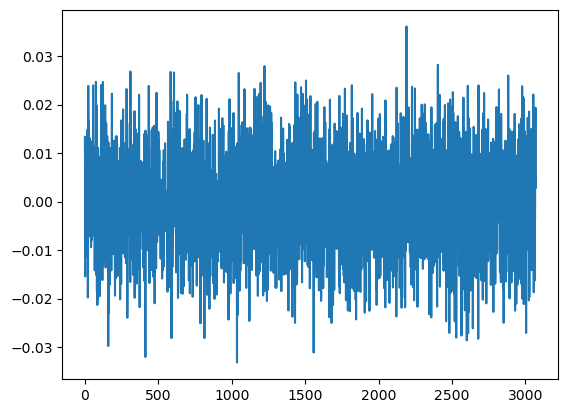

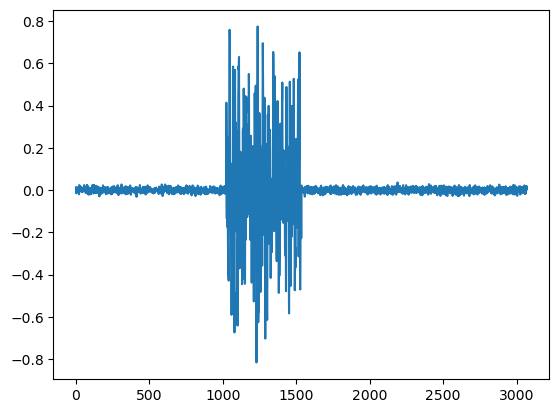

In [12]:
burst_signal = noise.copy()
burst_signal[int(burst_start * Fs):int(burst_start * Fs + len(burst))] = burst
np.save('/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/signal_burst_1.npy', burst_signal)

plt.plot(noise)
plt.figure()
plt.plot(burst_signal)

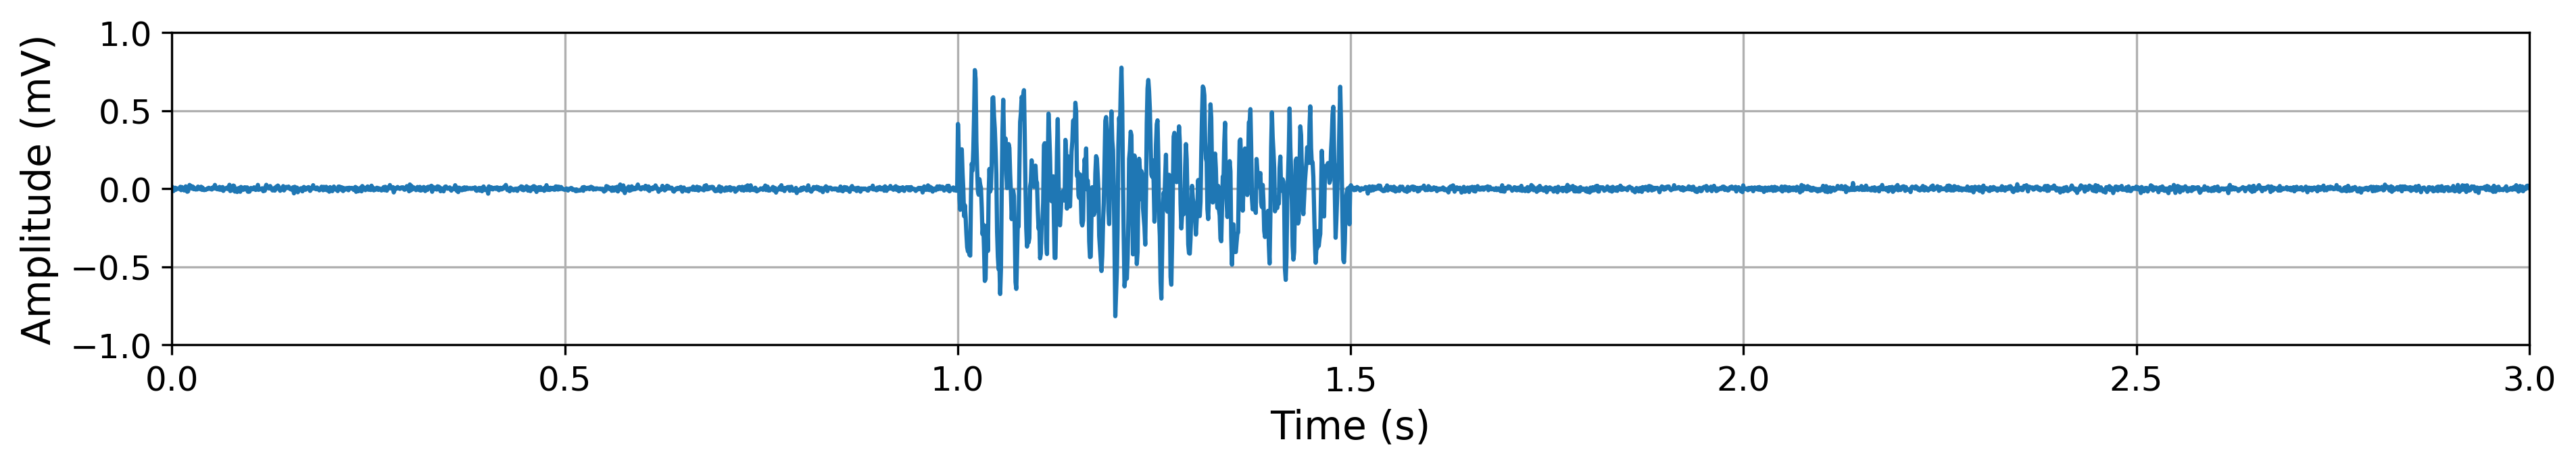

In [13]:
fig, ax = plt.subplots(figsize=(15, 2), dpi=300)
ax.set_xlabel("Time (s)", fontsize=fontsize_labels)
ax.set_ylabel("Amplitude (mV)", fontsize=fontsize_labels)
ax.set_xlim(0,3)
ax.set_ylim(-1,1)

ax.plot(jnp.linspace(0, len(burst_signal)/Fs, len(burst_signal)), burst_signal)

ax.tick_params(axis='both', labelsize=fontsize_ticks)
ax.grid(True)

In [14]:
MNF_1

[92.67754020405637]

In [15]:
def get_onset_offset(matrix, burst_start, burst_duration, t, Fs, smooth_sigma, plot=False, std_threshold=None):
    first_indices = []
    last_indices = []

    for row in matrix:
        first_idx, last_idx = superlet.find_plateau_region(
            row, burst_start, burst_duration, t, Fs,
            smooth_sigma=smooth_sigma, plot=plot, std_threshold=std_threshold
        )
        first_indices.append(first_idx)
        last_indices.append(last_idx)

    return t[first_indices], t[last_indices]

In [16]:
plot_scalogram = True

In [17]:
y = burst_signal
frange = np.linspace(10,500,int(Fs/2)) 
norm = "freq-sqrt"

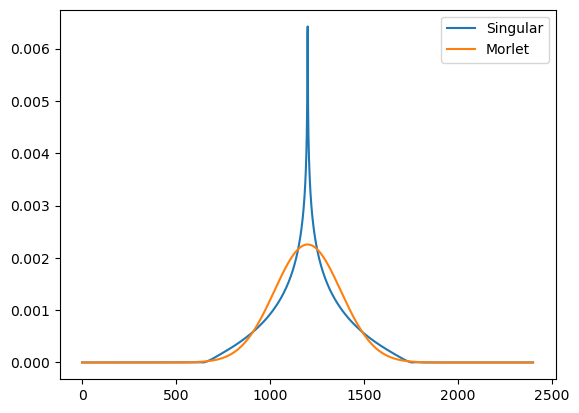

In [23]:
import matplotlib.pyplot as plt

plt.plot(np.abs(sst.singularSuperlet(90, 100, 1000, "freq-sqrt")))
plt.plot(np.abs(cwt.morlet(90, 100, 1000, "freq-sqrt")))
plt.legend(["Singular", "Morlet"])
plt.show()



SST params: step=98, baseCycle=4
SLT params: baseCycle=8, o_min=1, o_max=118
CWT params: step=69, baseCycle=3
Our CWT params: cycles=39
    SST time: 0.207s, CWT time: 0.194s, SLT time: 9.606s, Our CWT: 0.153s


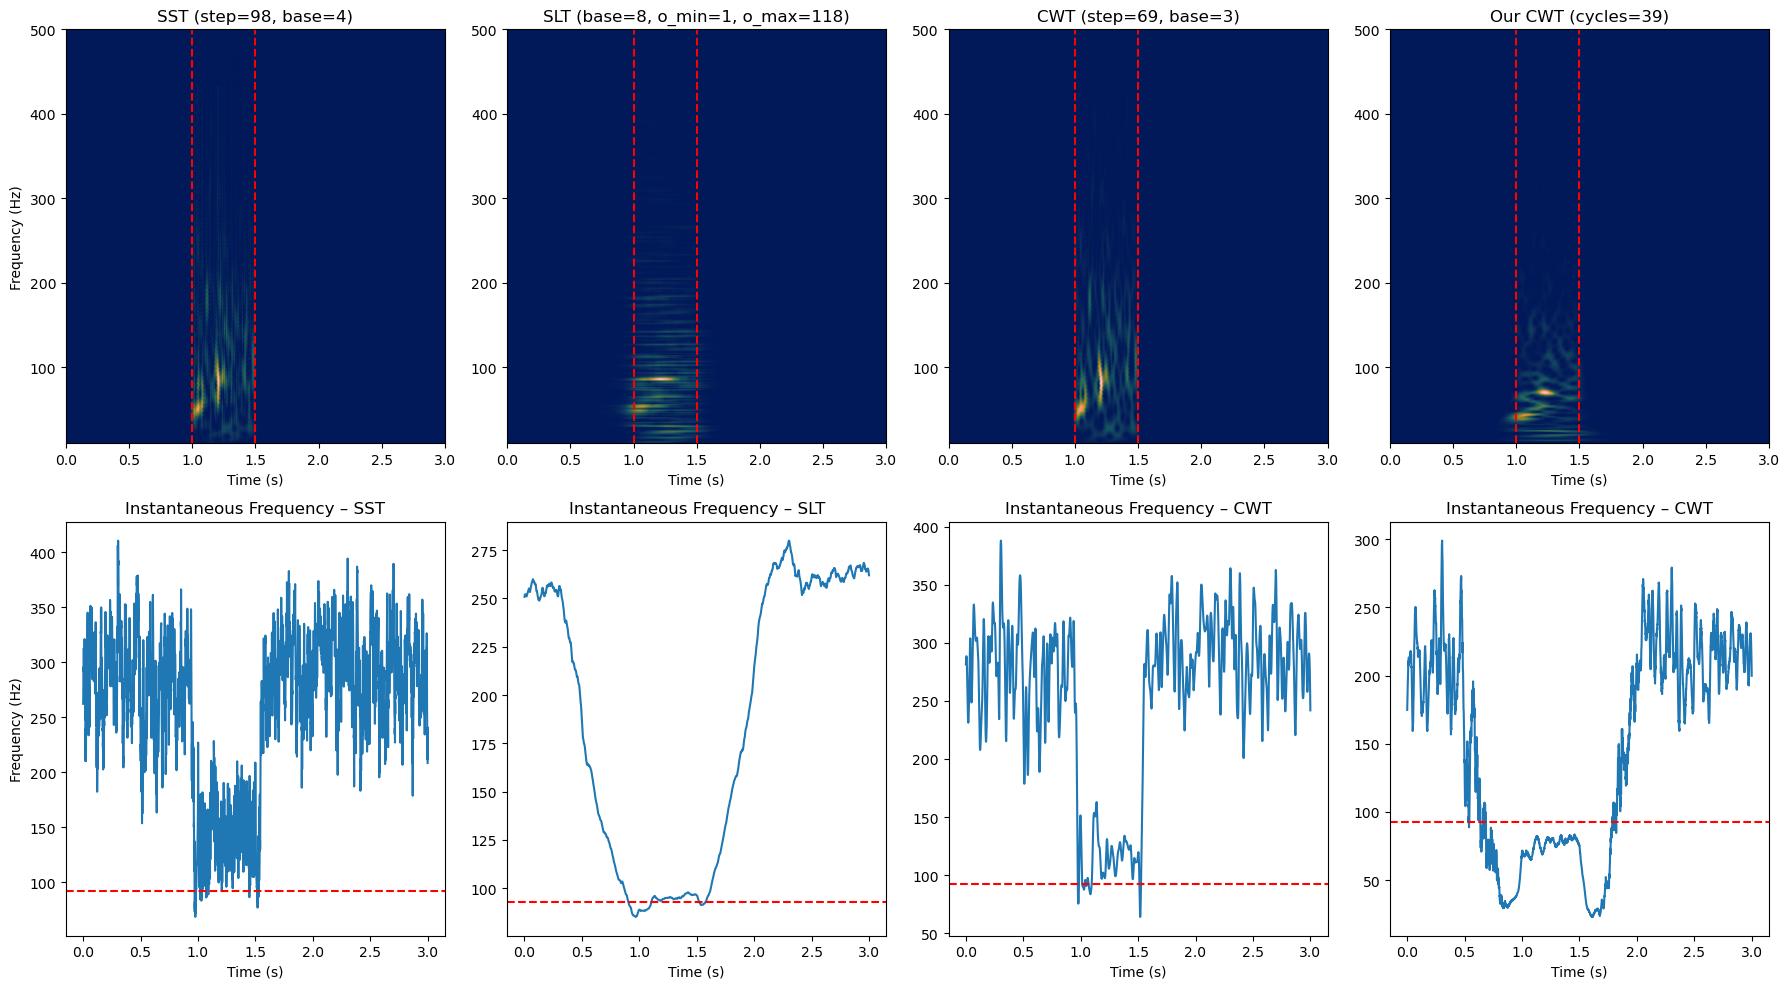

Reference MNF = 92.67754020405637 Hz
    Estimated MNF (SST) = 139.56200234539037 Hz
    Estimated MNF (SLT) = 94.06551424596711 Hz
    Estimated MNF (CWT) = 114.43921903490501 Hz
    Estimated MNF (Our CWT) = 76.31255087678483 Hz
Reference onset = 1 s, reference offset = 1.5 s
    Estimated onset (SST) = 0.9963303382448713 s, offset = 1.492015146735591 s
    Estimated onset (SLT) = 0.9440061767339629 s, offset = 1.5494831946027352 s
    Estimated onset (CWT) = 1.001661205633344 s, offset = 1.4689516088000651 s
    Estimated onset (CWT) = 0.9957274198143928 s, offset = 1.4790008852979488 s

SST params: step=9, baseCycle=27
SLT params: baseCycle=17, o_min=1, o_max=142
CWT params: step=11, baseCycle=3
Our CWT params: cycles=43
    SST time: 9.678s, CWT time: 0.861s, SLT time: 11.300s, Our CWT: 0.149s


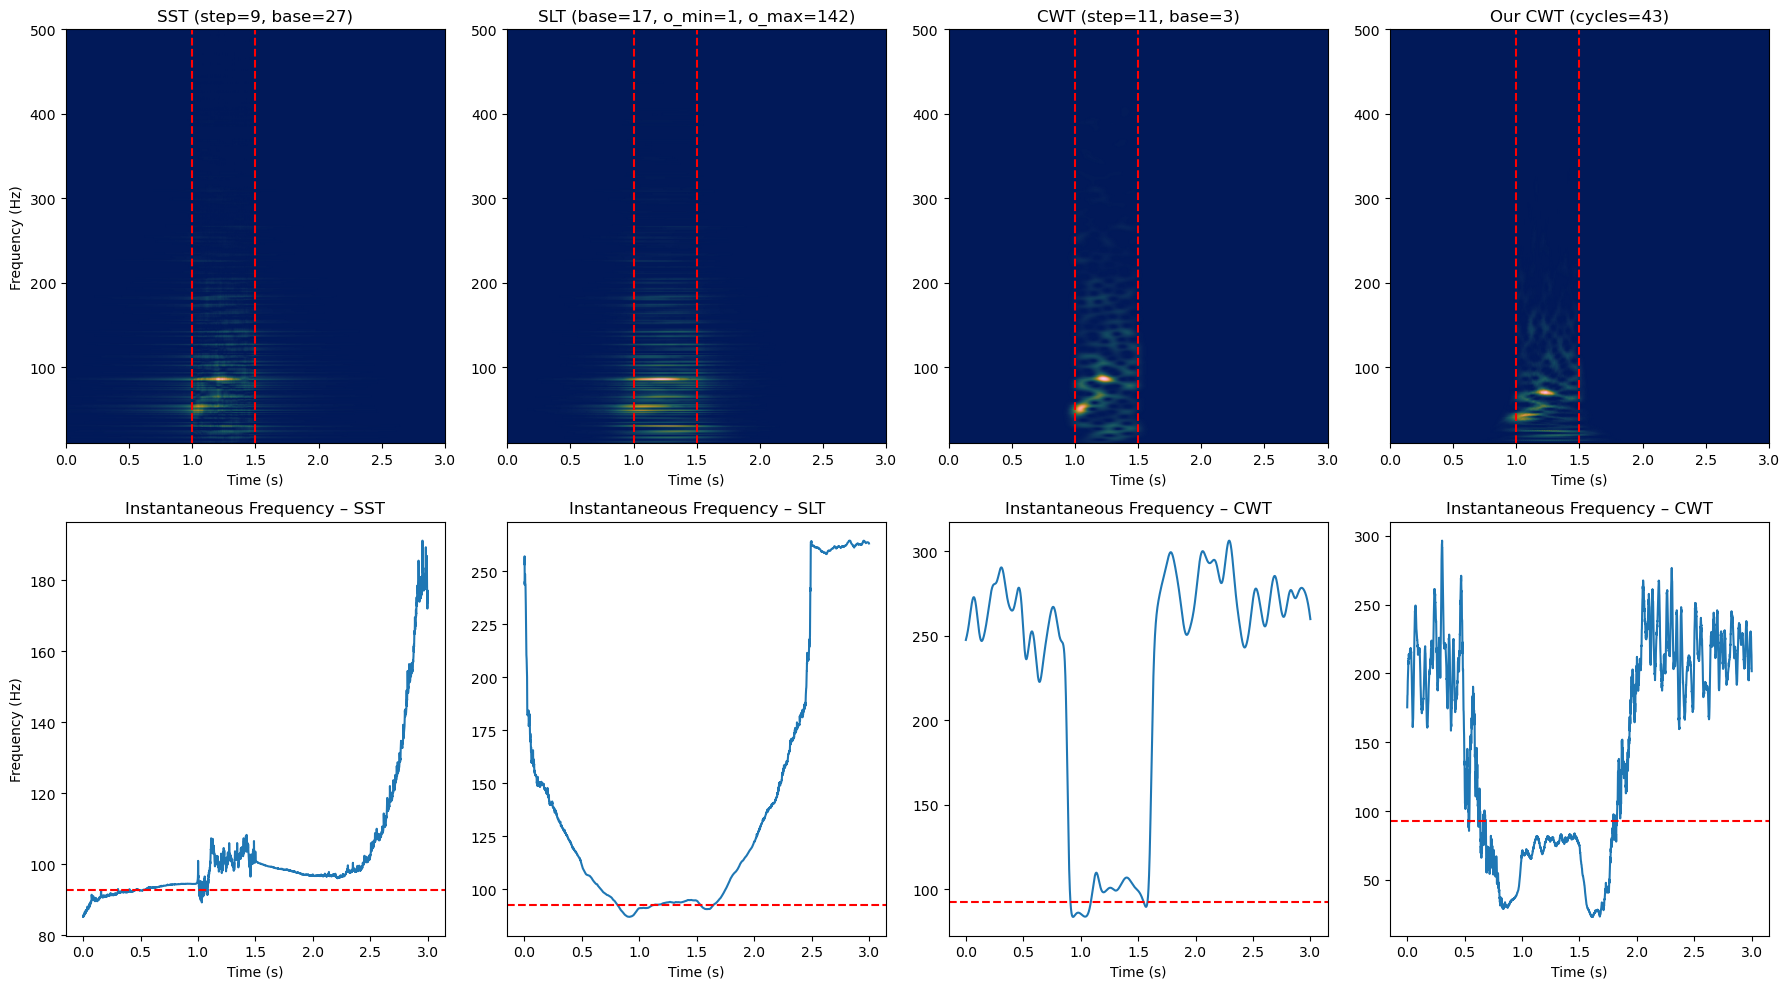

Reference MNF = 92.67754020405637 Hz
    Estimated MNF (SST) = 100.03516168745726 Hz
    Estimated MNF (SLT) = 93.36287217518657 Hz
    Estimated MNF (CWT) = 99.40261672721815 Hz
    Estimated MNF (Our CWT) = 76.48630765466714 Hz
Reference onset = 1 s, reference offset = 1.5 s
    Estimated onset (SST) = 0.8986155771735591 s, offset = 1.587812398241615 s
    Estimated onset (SLT) = 0.7396034730136765 s, offset = 1.7474083411348094 s
    Estimated onset (CWT) = 1.0079422419407358 s, offset = 1.4504633822451969 s
    Estimated onset (CWT) = 0.9953801693259524 s, offset = 1.4801513910371216 s

SST params: step=5, baseCycle=61
SLT params: baseCycle=8, o_min=4, o_max=103
CWT params: step=5, baseCycle=16
Our CWT params: cycles=1
    SST time: 39.450s, CWT time: 10.395s, SLT time: 8.993s, Our CWT: 0.162s


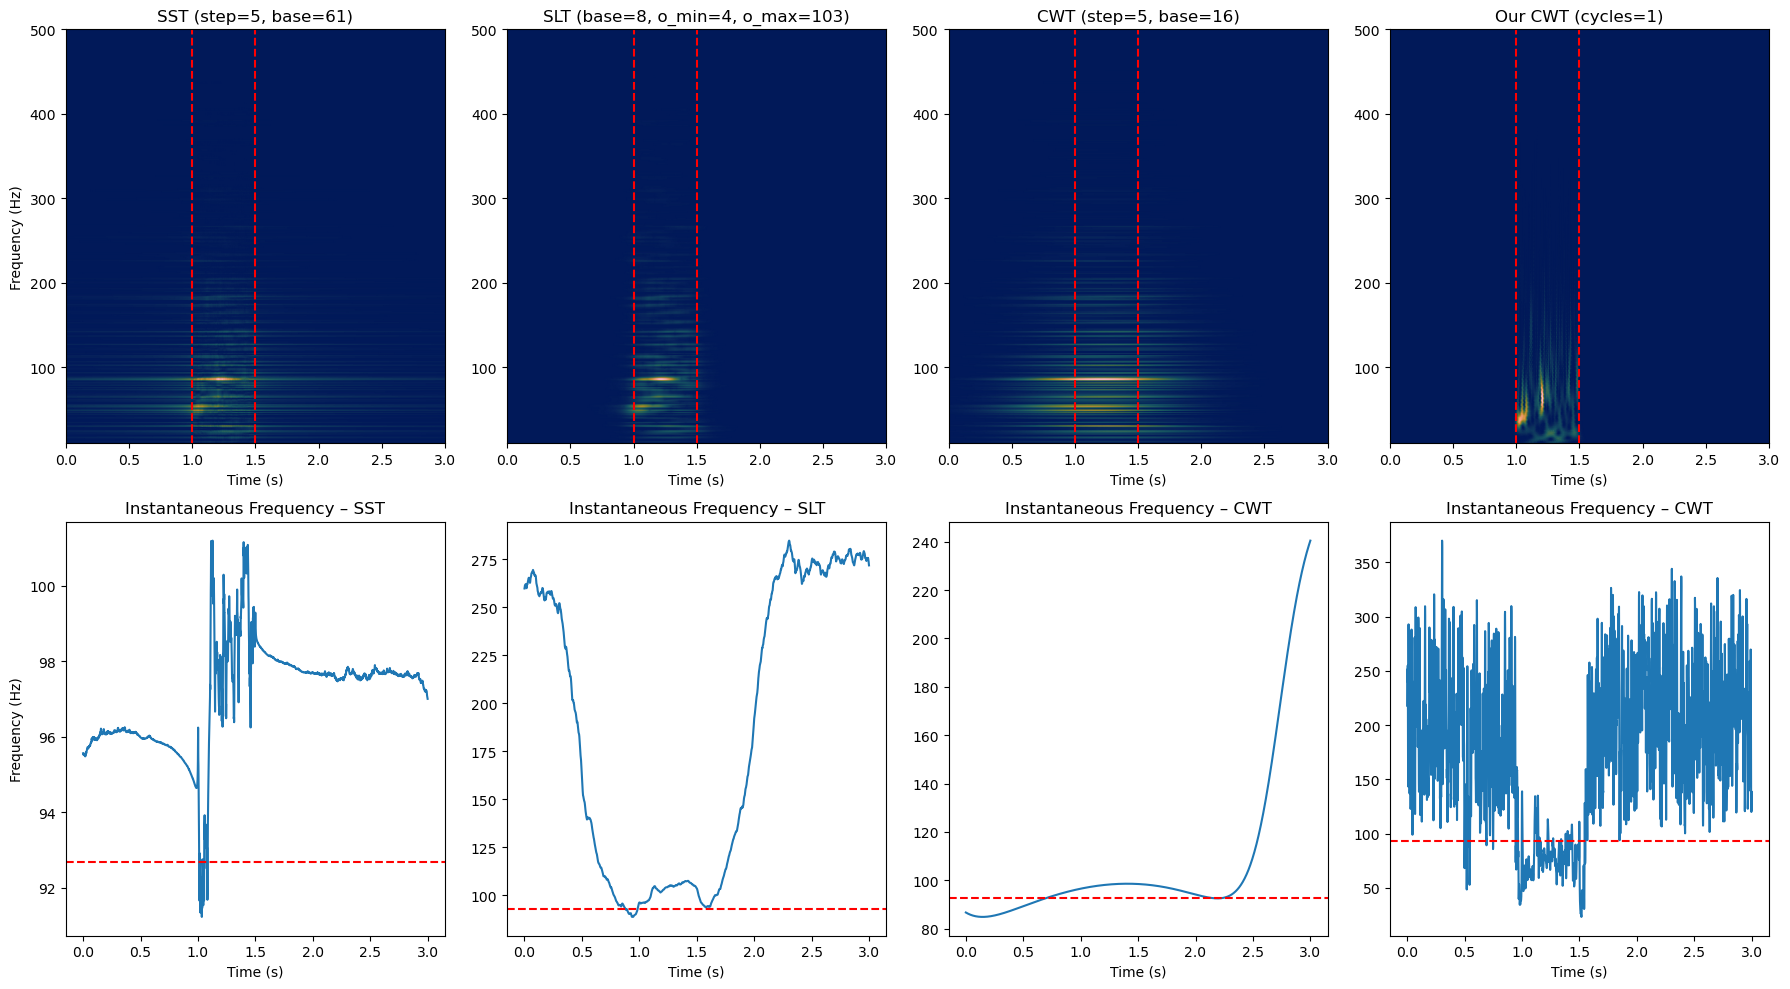

Reference MNF = 92.67754020405637 Hz
    Estimated MNF (SST) = 97.57739157828624 Hz
    Estimated MNF (SLT) = 103.02332576158963 Hz
    Estimated MNF (CWT) = 98.013749073835 Hz
    Estimated MNF (Our CWT) = 78.23644985560279 Hz
Reference onset = 1 s, reference offset = 1.5 s
    Estimated onset (SST) = 0.6093998036063172 s, offset = 1.8641570080999674 s
    Estimated onset (SLT) = 0.9489878856642788 s, offset = 1.5409030547867144 s
    Estimated onset (CWT) = 0.5045148923396288 s, offset = 1.9683130749348745 s
    Estimated onset (CWT) = 0.9909365078557474 s, offset = 1.4940929257570823 s
Cálculo finalizado.


In [19]:
import time
# Se asume que matplotlib.pyplot y cmasher están importados en el entorno.
# import matplotlib.pyplot as plt
# import cmasher as cmc 

# =========================================================================
# === DEFINICIÓN DE PARÁMETROS ÓPTIMOS ===

# 1. Parámetros óptimos para Singular Superlet Transform (SST): (step, base)
params_sst = [[98, 9, 5], [4, 27, 61]] 

# 2. Parámetros óptimos para Superlet Convencional (SLT): (base, o_min, o_max)
# Utilizamos una lista triple para base, o_min y o_max.
# (Ejemplo: 3 combinaciones optimizadas)
params_slt = [[8,17,8], [1,1,4], [118,142,103]] 

# 3. Parámetros óptimos para CWT (Morlet Adaptativa/Similar): (step, base)
# (Ejemplo: 3 combinaciones optimizadas)
params_cwt_opt = [[69,11,5], [3,3,16]] 

params_our_cwt = [39,43,1]
# =========================================================================


# Inicialización de listas de métricas 
mae_sst_f, std_sst_f = [], []
mae_slt_f, std_slt_f = [], []
mae_cwt_f, std_cwt_f = [], []
mae_our_cwt_f, std_our_cwt_f = [], []

mae_sst_t, std_sst_t = [], []
mae_slt_t, std_slt_t = [], []
mae_cwt_t, std_cwt_t = [], []
mae_our_cwt_t, std_our_cwt_t = [], []

params_list = []
smooth_sigma = 20

# Iteración sobre los parámetros óptimos para cada método
# sst_params será (step_sst, base_sst)
# slt_params será (base_slt, o_min_slt, o_max_slt)
# cwt_params será (step_cwt, base_cwt)
for (sst_params, slt_params, cwt_params, our_cwt_params) in zip(zip(*params_sst), zip(*params_slt), zip(*params_cwt_opt), params_our_cwt):
    # Parámetros SST
    step_sst, base_sst = sst_params
    # Parámetros SLT (NUEVA ESTRUCTURA)
    base_slt, o_min_slt, o_max_slt = slt_params
    # Parámetros CWT
    step_cwt, base_cwt = cwt_params
    
    cycles_our_cwt = our_cwt_params
    
    print(f"\n==============================")
    print(f"SST params: step={step_sst}, baseCycle={base_sst}")
    print(f"SLT params: baseCycle={base_slt}, o_min={o_min_slt}, o_max={o_max_slt}")
    print(f"CWT params: step={step_cwt}, baseCycle={base_cwt}")
    print(f"Our CWT params: cycles={cycles_our_cwt}")
       
    # --- 1. Cálculo SST (Singular Superlet) ---
    start_time = time.time()
    # SST devuelve o_min y o_max, calculados internamente usando 'step'
    sstRez, o_min_sst, o_max_sst = sst.sst(y, frange, Fs, base_sst, norm, step_sst)
    sst_time = time.time() - start_time

    # --- 2. Cálculo CWT (Morlet Adaptativa) ---
    start_time_cwt = time.time()
    # Utiliza step_cwt y base_cwt
    cwtRez = cwt.cwt(y, frange, Fs, base_cwt, norm, step_cwt) 
    cwt_time = time.time() - start_time_cwt

    # --- 3. Cálculo SLT (Superlet Convencional) ---
    start_time_slt = time.time()
    # Utiliza base_slt, o_min_slt, y o_max_slt
    wv, sltRez = superlet.adaptive_superlet_transform(
        y, frange, sampling_freq=Fs, base_cycle=base_slt, min_order=o_min_slt, max_order=o_max_slt, mode="mul"
    )
    slt_time = time.time() - start_time_slt
    sltRez_scalogram = np.array(jnp.abs(sltRez)**2)
    
    start_time_our_cwt = time.time()
    wavelet = f'cmor{cycles_our_cwt}-1.0'
    cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(y,wavelet,frange,Fs)
    cwt_scalogram = np.array(jnp.abs(cwtmatr)**2)
    our_cwt_time = time.time() - start_time_our_cwt

    print(f"    SST time: {sst_time:.3f}s, CWT time: {cwt_time:.3f}s, SLT time: {slt_time:.3f}s, Our CWT: {our_cwt_time:.3f}s")

    burst_times = np.array([[real_t_onset, real_t_offset]])
    
    eps = 1e-12
    # Calcular MAE en frecuencia
    instant_freq_sst = np.sum(sstRez * frange[:, None], axis=0) / (np.sum(sstRez, axis=0) + eps)
    instant_freq_slt = np.sum(sltRez_scalogram * frange[:, None], axis=0) / (np.sum(sltRez_scalogram, axis=0) + eps)
    instant_freq_cwt = np.sum(cwtRez * frange[:, None], axis=0) / (np.sum(cwtRez, axis=0) + eps)
    instant_freq_our_cwt = np.sum(cwt_scalogram * frange[:, None], axis=0) / (np.sum(cwt_scalogram, axis=0) + eps)

    if plot_scalogram:
        fig, axs = plt.subplots(2, 4, figsize=(18, 10))
        
        # SST scalogram
        for start, end in burst_times:
            axs[0, 0].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
        pcm0 = axs[0, 0].pcolormesh(t, frange, sstRez, shading='gouraud', cmap=cmc.batlow)
        axs[0, 0].set_title(f"SST (step={step_sst}, base={base_sst})")
        axs[0, 0].set_xlabel("Time (s)")
        axs[0, 0].set_ylabel("Frequency (Hz)")

        # SLT scalogram
        for start, end in burst_times:
            axs[0, 1].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
        pcm1 = axs[0, 1].pcolormesh(t, frange, sltRez_scalogram, shading='gouraud', cmap=cmc.batlow)
        axs[0, 1].set_title(f"SLT (base={base_slt}, o_min={o_min_slt}, o_max={o_max_slt})") # Título actualizado
        axs[0, 1].set_xlabel("Time (s)")

        # CWT scalogram
        for start, end in burst_times:
            axs[0, 2].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
        pcm2 = axs[0, 2].pcolormesh(t, frange, cwtRez, shading='gouraud', cmap=cmc.batlow)
        axs[0, 2].set_title(f"CWT (step={step_cwt}, base={base_cwt})") 
        axs[0, 2].set_xlabel("Time (s)")
        
        for start, end in burst_times:
            axs[0, 3].vlines([start, end], ymin=frange[0], ymax=frange[-1], color='r', linestyles='--')
        pcm2 = axs[0, 3].pcolormesh(t, frange, cwt_scalogram, shading='gouraud', cmap=cmc.batlow)
        axs[0, 3].set_title(f"Our CWT (cycles={cycles_our_cwt})") 
        axs[0, 3].set_xlabel("Time (s)")

        # Frecuencias Instantáneas
        axs[1, 0].plot(t, instant_freq_sst)
        axs[1, 0].axhline(MNF_1[0], color='r', linestyle='--')
        axs[1, 0].set_title("Instantaneous Frequency – SST")
        axs[1, 0].set_xlabel("Time (s)")
        axs[1, 0].set_ylabel("Frequency (Hz)")

        axs[1, 1].plot(t, instant_freq_slt)
        axs[1, 1].axhline(MNF_1[0], color='r', linestyle='--')
        axs[1, 1].set_title("Instantaneous Frequency – SLT")
        axs[1, 1].set_xlabel("Time (s)")

        axs[1, 2].plot(t, instant_freq_cwt)
        axs[1, 2].axhline(MNF_1[0], color='r', linestyle='--')
        axs[1, 2].set_title("Instantaneous Frequency – CWT")
        axs[1, 2].set_xlabel("Time (s)")
        
        axs[1, 3].plot(t, instant_freq_our_cwt)
        axs[1, 3].axhline(MNF_1[0], color='r', linestyle='--')
        axs[1, 3].set_title("Instantaneous Frequency – CWT")
        axs[1, 3].set_xlabel("Time (s)")
        
        plt.tight_layout()
        plt.show()

    instant_freq_burst_sst = instant_freq_sst[start_idx:end_idx]
    instant_freq_burst_slt = instant_freq_slt[start_idx:end_idx]
    instant_freq_burst_cwt = instant_freq_cwt[start_idx:end_idx]
    instant_freq_burst_our_cwt = instant_freq_our_cwt[start_idx:end_idx]
    print(f'Reference MNF = {MNF_1[0]} Hz')
    
    # MAE Frecuencia SST
    print(f'    Estimated MNF (SST) = {np.mean(instant_freq_burst_sst)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_freq_burst_sst, MNF_1[0])
    mae_sst_f.append(mae_f)
    std_sst_f.append(std_f)

    # MAE Frecuencia SLT
    print(f'    Estimated MNF (SLT) = {np.mean(instant_freq_burst_slt)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_freq_burst_slt, MNF_1[0])
    mae_slt_f.append(mae_f)
    std_slt_f.append(std_f)

    # MAE Frecuencia CWT
    print(f'    Estimated MNF (CWT) = {np.mean(instant_freq_burst_cwt)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_freq_burst_cwt, MNF_1[0])
    mae_cwt_f.append(mae_f)
    std_cwt_f.append(std_f)

    print(f'    Estimated MNF (Our CWT) = {np.mean(instant_freq_burst_our_cwt)} Hz')
    mae_f, std_f = superlet.calculate_mae(instant_freq_burst_our_cwt, MNF_1[0])
    mae_our_cwt_f.append(mae_f)
    std_our_cwt_f.append(std_f) 
    
    energia_temporal_sst = sstRez
    energia_temporal_slt = sltRez_scalogram
    energia_temporal_cwt = cwtRez
    energia_temporal_our_cwt = cwt_scalogram
    
    first_indices_sst = []
    last_indices_sst = []
    first_indices_cwt = []
    last_indices_cwt = []
    first_indices_our_cwt = []
    last_indices_our_cwt = []
    first_indices_slt = []
    last_indices_slt = []
    
    for row in energia_temporal_sst:
        first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, Fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
        first_indices_sst.append(first_index)
        last_indices_sst.append(last_index)
        
    t_onset_sst = t[first_indices_sst]
    t_offset_sst = t[last_indices_sst]
    
    for row in energia_temporal_cwt:
        first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, Fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
        first_indices_cwt.append(first_index)
        last_indices_cwt.append(last_index)
        
    t_onset_cwt = t[first_indices_cwt]
    t_offset_cwt = t[last_indices_cwt]
    
    for row in energia_temporal_our_cwt:
        first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, Fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
        first_indices_our_cwt.append(first_index)
        last_indices_our_cwt.append(last_index)
        
    t_onset_our_cwt = t[first_indices_our_cwt]
    t_offset_our_cwt = t[last_indices_our_cwt]
    
    for row in energia_temporal_slt:
        first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, Fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
        first_indices_slt.append(first_index)
        last_indices_slt.append(last_index)
        
    t_onset_slt = t[first_indices_slt]
    t_offset_slt = t[last_indices_slt]
    

    print(f'Reference onset = {real_t_onset} s, reference offset = {real_t_offset} s')
    
    # MAE Tiempo SST
    print(f'    Estimated onset (SST) = {np.mean(t_onset_sst)} s, offset = {np.mean(t_offset_sst)} s')
    mae_t, std_t = superlet.calculate_mae((t_onset_sst, t_offset_sst), (real_t_onset, real_t_offset))
    mae_sst_t.append(mae_t)
    std_sst_t.append(std_t)

    # MAE Tiempo SLT
    print(f'    Estimated onset (SLT) = {np.mean(t_onset_slt)} s, offset = {np.mean(t_offset_slt)} s')
    mae_t, std_t = superlet.calculate_mae((t_onset_slt, t_offset_slt), (real_t_onset, real_t_offset))
    mae_slt_t.append(mae_t)
    std_slt_t.append(std_t)

    # MAE Tiempo CWT
    print(f'    Estimated onset (CWT) = {np.mean(t_onset_cwt)} s, offset = {np.mean(t_offset_cwt)} s')
    mae_t, std_t = superlet.calculate_mae((t_onset_cwt, t_offset_cwt), (real_t_onset, real_t_offset))
    mae_cwt_t.append(mae_t)
    std_cwt_t.append(std_t)
    
    # MAE Tiempo CWT
    print(f'    Estimated onset (CWT) = {np.mean(t_onset_our_cwt)} s, offset = {np.mean(t_offset_our_cwt)} s')
    mae_t, std_t = superlet.calculate_mae((t_onset_our_cwt, t_offset_our_cwt), (real_t_onset, real_t_offset))
    mae_our_cwt_t.append(mae_t)
    std_our_cwt_t.append(std_t)

    params_list.append({
        'SST': (step_sst, base_sst),
        'SLT': (base_slt, o_min_slt, o_max_slt),
        'CWT': (step_cwt, base_cwt),
        'Our CWT': (cycles_our_cwt)
    })


print("Cálculo finalizado.")

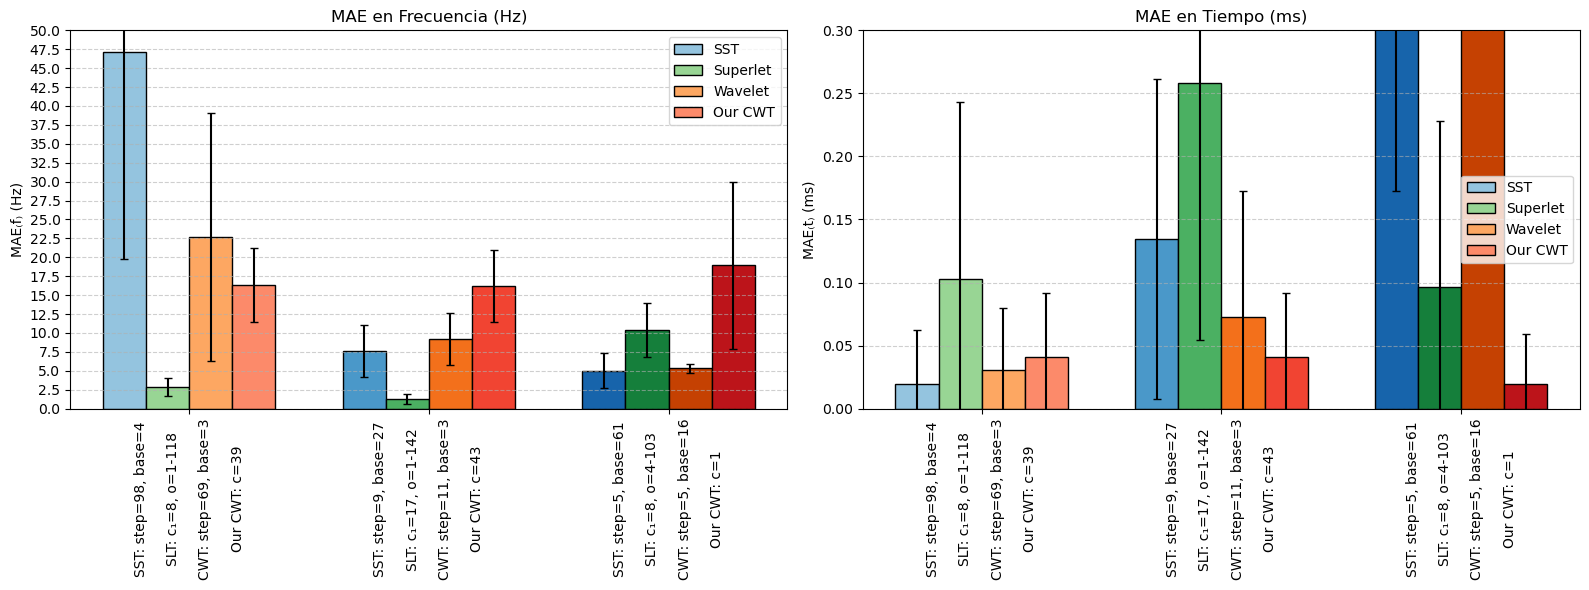

In [20]:
# ====================== CONFIGURACIÓN ======================

num_params = len(params_list)
x = np.arange(num_params)
bar_width = 0.18

# Desplazamiento horizontal de cada método
offsets = {
    "SST":     -1.5 * bar_width,
    "Superlet": -0.5 * bar_width,
    "Wavelet":   0.5 * bar_width,
    "Our CWT":   1.5 * bar_width
}

# Colores base para cada método
colores_base = {
    "SST":     plt.colormaps["Blues"],
    "Superlet": plt.colormaps["Greens"],
    "Wavelet":  plt.colormaps["Oranges"],
    "Our CWT":  plt.colormaps["Reds"]
}

# Tonos diferentes para cada parámetro (0.4 → 0.8)
tonos = np.linspace(0.4, 0.8, num_params)


# ====================== ETIQUETAS ======================

labels = []
for i in range(num_params):

    step_sst, base_sst = params_sst[0][i], params_sst[1][i]
    c1_slt, omin_slt, omax_slt = params_slt[0][i], params_slt[1][i], params_slt[2][i]
    step_cwt, base_cwt = params_cwt_opt[0][i], params_cwt_opt[1][i]
    c_our = params_our_cwt[i]

    label = (
        f"SST: step={step_sst}, base={base_sst}\n\n"
        f"SLT: c₁={c1_slt}, o={omin_slt}-{omax_slt}\n\n"
        f"CWT: step={step_cwt}, base={base_cwt}\n\n"
        f"Our CWT: c={c_our}"
    )
    labels.append(label)


# ====================== FIGURA CON DOS SUBPLOTS ======================

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Función para dibujar barras
def plot_bars(ax, nombre, maes, stds):
    ax.bar(
        x + offsets[nombre],
        maes,
        width=bar_width,
        color=[colores_base[nombre](tonos[i]) for i in range(num_params)],
        edgecolor="black",
        label=nombre
    )
    ax.errorbar(
        x + offsets[nombre],
        maes,
        yerr=stds,
        fmt="none",
        ecolor="black",
        capsize=3
    )


# ====================== SUBPLOT 1: MAE FRECUENCIA ======================

ax = axes[0]
plot_bars(ax, "SST",      mae_sst_f,      std_sst_f)
plot_bars(ax, "Superlet", mae_slt_f,      std_slt_f)
plot_bars(ax, "Wavelet",  mae_cwt_f,      std_cwt_f)
plot_bars(ax, "Our CWT",  mae_our_cwt_f,  std_our_cwt_f)

ax.set_title("MAE en Frecuencia (Hz)")
ax.set_ylabel("MAE₍f₎ (Hz)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.set_ylim(0, 50) 
ax.set_yticks(np.arange(0, 52.5, 2.5))
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend()


# ====================== SUBPLOT 2: MAE TIEMPO ======================

ax = axes[1]
plot_bars(ax, "SST",      mae_sst_t,      std_sst_t)
plot_bars(ax, "Superlet", mae_slt_t,      std_slt_t)
plot_bars(ax, "Wavelet",  mae_cwt_t,      std_cwt_t)
plot_bars(ax, "Our CWT",  mae_our_cwt_t,  std_our_cwt_t)

ax.set_title("MAE en Tiempo (ms)")
ax.set_ylabel("MAE₍t₎ (ms)")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.set_ylim(0, 0.3) 
ax.set_yticks(np.arange(0, 0.35, 0.05))
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend()


plt.tight_layout()
plt.show()

# DEMO

In [8]:
# #import required packages
import numpy as np
# import matplotlib.pyplot as plt
# 
# #import the functions
# from SingularSuperletPY import sst
# # from SingularSuperletPY import cwt #uncomment if you want to compare the method (SST) with continuous wavelet transform (CWT)
# 
# filename = "\path\to\your\data"   # define the path to your data
# y        = np.load(filename)	  # load your data
# Fs       = 1000.0                 # define sampling rate in Hz, replace with the sampling rate of your file

# define parameters for singular superlet transform, consult the research paper above for further details
frange    = np.arange(1,2000,1)   # frequency range of interest for performing the time frequency decomposition
norm      = "energy"      # normalization to be used, options are: "modulus-integral", "unit", "frequency-sqrt" and "energy". Check the function normalize in waveletHelper.py for further details
step      = 250                   # adaptive parameter for number of cycles increment per frequency band
baseCycle = 3                     # number of baseline cycles to build the adaptive increments on 

# perform time frequency decomposition
sstRez = sst.sst(y, frange, Fs, baseCycle, norm, step) # perform sst,  returns the scalogram output that is frequencyPoints x timePoints
# cwtRez = cwt.cwt(y, frange, Fs, baseCycle, norm, step) # perform cwt,  uncomment if you wish to make comparisons with cwt, returns the scalogram output that is frequencyPoints x timePoints


NameError: name 'y' is not defined